In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [23]:
df = pd.read_csv("crop_yield.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 62.9 MB


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [24]:
df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)
categorical_cols = ["Region", "Soil_Type", "Crop", "Weather_Condition"]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# generally here As rainfall increases, crop yield generally increases until an optimal point.

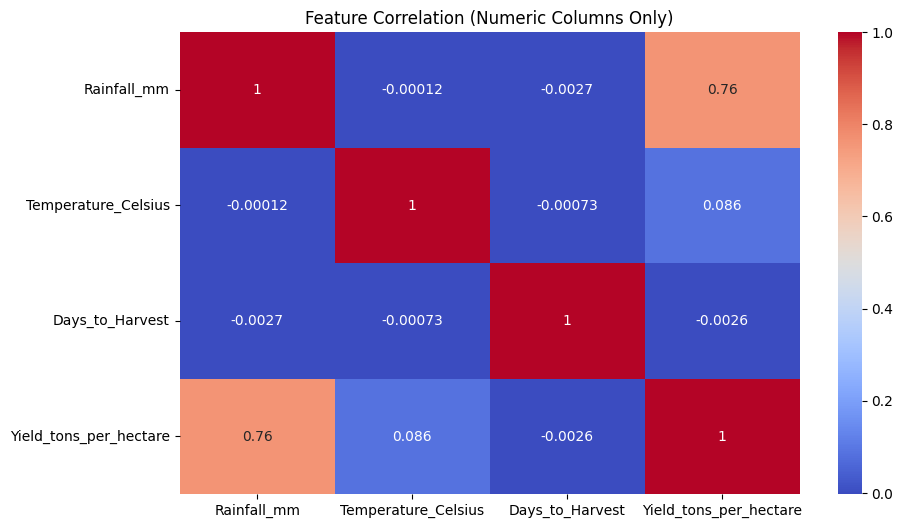

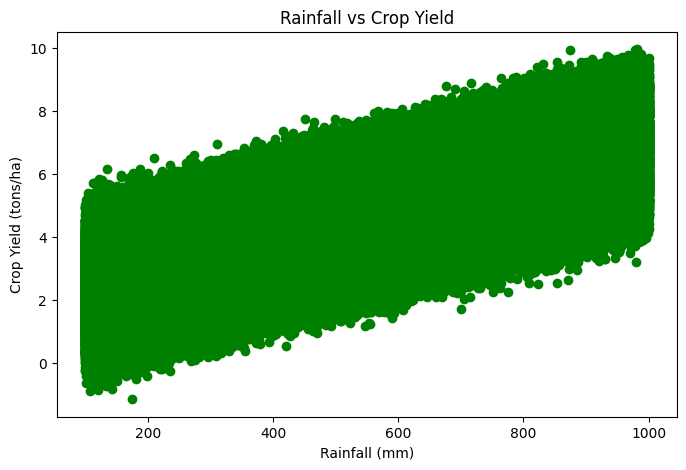

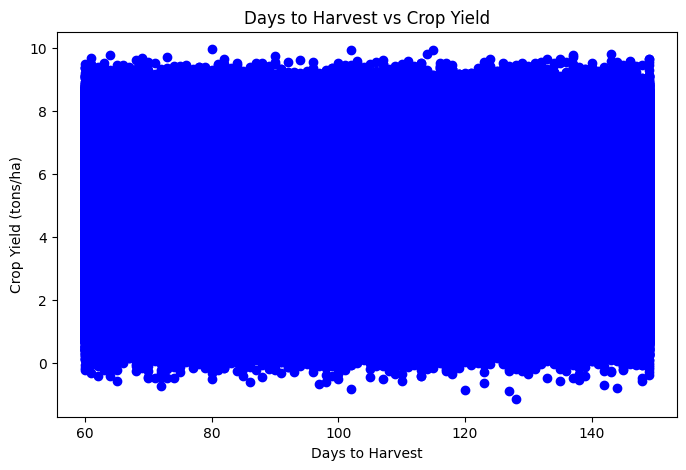

In [25]:
numeric_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation (Numeric Columns Only)")
plt.show()
plt.figure(figsize=(8,5))
plt.scatter(df["Rainfall_mm"], df["Yield_tons_per_hectare"], color="green")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Crop Yield (tons/ha)")
plt.title("Rainfall vs Crop Yield")
plt.show()
plt.figure(figsize=(8,5))
plt.scatter(df["Days_to_Harvest"], df["Yield_tons_per_hectare"], color="blue")
plt.xlabel("Days to Harvest")
plt.ylabel("Crop Yield (tons/ha)")
plt.title("Days to Harvest vs Crop Yield")
plt.show()


In [26]:
X = df.drop("Yield_tons_per_hectare", axis=1) ## since we want to predict the yield i removed that column so that the module uses the rest to predict.
y = df["Yield_tons_per_hectare"] # # the y is what we want to predict.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
lr_model = SGDRegressor(max_iter=1000, learning_rate='invscaling', random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))



Linear Regression R2: 0.912877623001093
Linear Regression MSE: 0.2511691757584565


In [29]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)#for decision tree regresion

print("Decision Tree R2:", r2_score(y_test, y_pred_tree))
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_tree))

Decision Tree R2: 0.896655399835329
Decision Tree MSE: 0.29793698170991467


In [ ]:
rf_model = RandomForestRegressor(n_estimators=50, random_state=42) # this was taking way to long to load, so give it about 8 minutes depending on your cpu
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest R2: 0.9066100233331453
Random Forest MSE: 0.26923833200521635


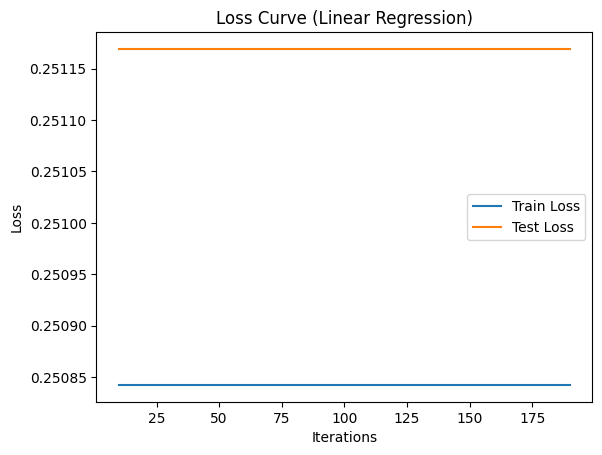

In [31]:
train_errors = []
test_errors = []

for i in range(10, 200, 10):
    model = SGDRegressor(max_iter=i, learning_rate='invscaling', random_state=42)
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

plt.plot(range(10,200,10), train_errors, label="Train Loss")
plt.plot(range(10,200,10), test_errors, label="Test Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve (Linear Regression)")
plt.legend()
plt.show()


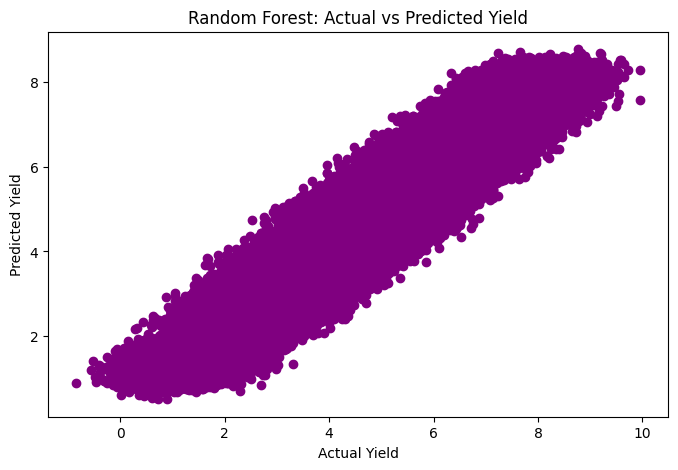

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, color='purple')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted Yield")
plt.show()

In [33]:
joblib.dump(rf_model, "best_crop_yield_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print(" The best model and scaler has been saved")

 The best model and scaler has been saved
